# 📚 Book Recommendation System — Modeling & Evaluation
**Course:** DS 423 — Machine Learning with Large Datasets  
**Group:** 06 | **University:** Duy Tan University, Da Nang

| Member | ID | Role |
|---|---|---|
| Lê Kim Dũng | 28211452455 | Data & Analysis Lead |
| Võ Minh Chính | 28212306297 | Modeling & Evaluation Lead |

---

### Notebook Contents (Võ Minh Chính's tasks)
1. Environment Setup & Data Loading
2. Collaborative Filtering (SVD) & Evaluation (RMSE, MAE)
3. Precision@K and Recall@K Evaluation
4. Content-Based Filtering (Cosine Similarity)
5. Top-N Recommendation Function


In [3]:
%pip install scikit-surprise pandas numpy scikit-learn matplotlib seaborn --quiet


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Surprise for Collaborative Filtering
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Sklearn for Content-Based Filtering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully.")


All libraries imported successfully.


## 1. Environment Setup & Data Loading
Loading the datasets prepared by Lê Kim Dũng in the previous step.

In [5]:
# Load cleaned books data with features
books_df = pd.read_csv('data/books_cleaned_with_features.csv')

# Load ratings data
ratings_df = pd.read_csv('data/ratings.csv')

# Since ratings dataset is very large, for training time purposes we can sample it or use all of it.
# Here we use the full dataset.
print(f"Books shape: {books_df.shape}")
print(f"Ratings shape: {ratings_df.shape}")


Books shape: (10000, 26)
Ratings shape: (981756, 3)


## 2. Collaborative Filtering (SVD) & Evaluation
We use Singular Value Decomposition (SVD), a powerful matrix factorization technique for collaborative filtering.

In [6]:
# Define Reader scale for Goodbooks (1 to 5)
reader = Reader(rating_scale=(1, 5))

# Load data into Surprise Dataset format
# Columns must correspond to user id, item id and ratings (in that order)
data = Dataset.load_from_df(ratings_df[['user_id', 'book_id', 'rating']], reader)

# Train-test split (80% train, 20% test)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print("Data split into train and test sets.")


Data split into train and test sets.


 Completed Epoch  1 | Train RMSE: 0.9117 | Test RMSE: 0.9227 | Time: 9.8s
 Completed Epoch  5 | Train RMSE: 0.8180 | Test RMSE: 0.8609 | Time: 10.7s
 Completed Epoch 10 | Train RMSE: 0.7764 | Test RMSE: 0.8472 | Time: 15.5s
 Completed Epoch 15 | Train RMSE: 0.7441 | Test RMSE: 0.8424 | Time: 16.4s
 Completed Epoch 20 | Train RMSE: 0.7104 | Test RMSE: 0.8402 | Time: 19.6s

 Training completed for final model (20 epochs).


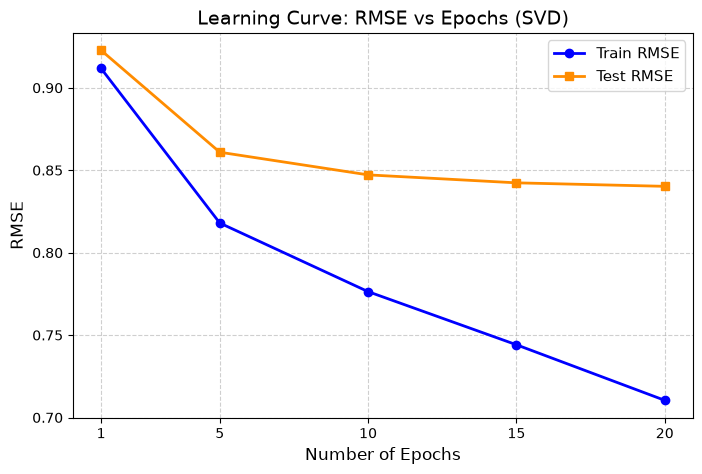

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import accuracy
import time


epochs_to_test = [1, 5, 10, 15, 20]
train_rmse_list = []
test_rmse_list = []

# Build testset for train data to calculate Train RMSE
train_eval_set = trainset.build_testset()

for n in epochs_to_test:
    start_time = time.time()
    algo = SVD(n_factors=50, n_epochs=n, random_state=42, verbose=False)
    algo.fit(trainset)
    
    # Predict and calculate RMSE
    train_preds = algo.test(train_eval_set)
    test_preds = algo.test(testset)
    
    train_rmse = accuracy.rmse(train_preds, verbose=False)
    test_rmse = accuracy.rmse(test_preds, verbose=False)
    
    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)
    
    elapsed = time.time() - start_time
    print(f" Completed Epoch {n:2d} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f} | Time: {elapsed:.1f}s")

# Khởi tạo mô hình cuối cùng để sử dụng
svd = SVD(n_factors=50, n_epochs=20, random_state=42, verbose=False)
svd.fit(trainset)
print("\n Training completed for final model (20 epochs).")

# Vẽ biểu đồ Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_to_test, train_rmse_list, marker='o', label='Train RMSE', color='blue', linewidth=2)
plt.plot(epochs_to_test, test_rmse_list, marker='s', label='Test RMSE', color='darkorange', linewidth=2)
plt.title('Learning Curve: RMSE vs Epochs (SVD)', fontsize=14)
plt.xlabel('Number of Epochs', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.xticks(epochs_to_test)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [11]:
# Predict on the test set
predictions = svd.test(testset)

# Calculate RMSE and MAE
rmse = accuracy.rmse(predictions, verbose=True)
mae = accuracy.mae(predictions, verbose=True)


RMSE: 0.8402
MAE:  0.6566


### 📊 Visualizing Prediction Errors
A good model should have errors distributed around 0.

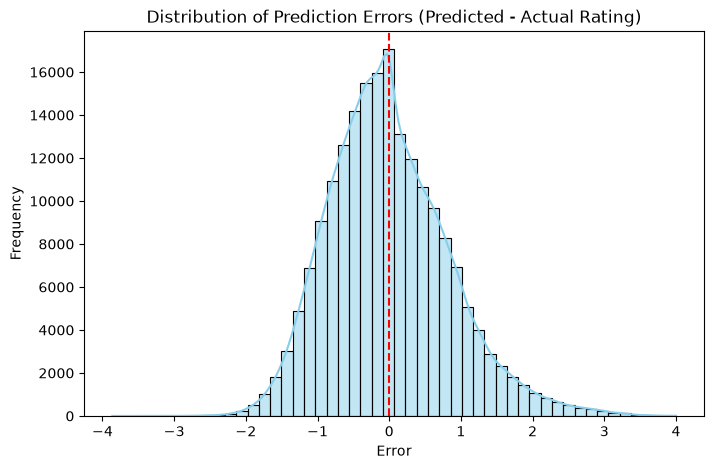

In [18]:
# Visualizing the distribution of prediction errors
errors = [pred.est - pred.r_ui for pred in predictions]

plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Prediction Errors (Predicted - Actual Rating)')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()


## 3. Precision@K and Recall@K Evaluation
Calculating the ranking metrics for top-K recommendation.

In [13]:
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """
    Return precision and recall at k metrics for each user.
    threshold: rating above which an item is considered relevant.
    """
    # First map the predictions to each user.
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    
    precisions = dict()
    recalls = dict()
    
    for uid, user_ratings in user_est_true.items():
        # Sort user ratings by estimated value
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        
        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        
        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        
        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])
        
        # Precision@K: Proportion of recommended items that are relevant
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        
        # Recall@K: Proportion of relevant items that are recommended
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
        
    return precisions, recalls

# Calculate precision and recall at K=10
precisions, recalls = precision_recall_at_k(predictions, k=10, threshold=3.5)

# Average across all users
mean_precision = sum(prec for prec in precisions.values()) / len(precisions)
mean_recall = sum(rec for rec in recalls.values()) / len(recalls)

print(f"Precision@10: {mean_precision:.4f}")
print(f"Recall@10:    {mean_recall:.4f}")


Precision@10: 0.6639
Recall@10:    0.7101


## 4. Content-Based Filtering (Cosine Similarity)
Using the `content_features` engineered previously to recommend similar books.

In [14]:
# Create TF-IDF matrix
tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=1, stop_words='english')

# Fill NaN with empty string just in case
books_df['content_features'] = books_df['content_features'].fillna('')

print("Calculating TF-IDF matrix...")
tfidf_matrix = tfidf.fit_transform(books_df['content_features'])

print("Calculating Cosine Similarity matrix...")
# Use linear_kernel for faster cosine similarity calculation
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print("Content-Based Filtering components ready.")


Calculating TF-IDF matrix...
Calculating Cosine Similarity matrix...
Content-Based Filtering components ready.


In [19]:
def get_content_based_recommendations(title, n=10):
    """
    Get top n similar books based on book title using content features.
    """
    # Get index of the book that matches the title
    indices = pd.Series(books_df.index, index=books_df['title']).drop_duplicates()
    
    if title not in indices:
        return f"Book '{title}' not found in the dataset."
    
    idx = indices[title]
    
    # Get pairwise similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort books based on similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get scores of the top n most similar books (ignoring the book itself at index 0)
    sim_scores = sim_scores[1:n+1]
    
    # Get book indices
    book_indices = [i[0] for i in sim_scores]
    
    return books_df[['title', 'authors', 'average_rating']].iloc[book_indices]

# Example recommendation
print("Content-based recommendations for 'The Hunger Games (The Hunger Games, #1)':")
display(get_content_based_recommendations('The Hunger Games (The Hunger Games, #1)', n=5))


Content-based recommendations for 'The Hunger Games (The Hunger Games, #1)':


,title,authors,average_rating
16,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,4.30
19,"Mockingjay (The Hunger Games, #3)",Suzanne Collins,4.03
506,The Hunger Games Trilogy Boxset (The Hunger Ga...,Suzanne Collins,4.49
716,The Hunger Games: Official Illustrated Movie C...,Kate Egan,4.51
1354,The Hunger Games Tribute Guide,Emily Seife,4.40


## 5. Top-N Hybrid Recommendation Function
Combining Collaborative Filtering (predicting user's rating) and generating a final top-N list.

In [16]:
def get_top_n_recommendations_for_user(user_id, n=10):
    """
    Recommends Top-N books for a specific user using the trained SVD Collaborative Filtering model.
    Only considers books the user hasn't rated yet.
    """
    # Get list of all book ids
    all_book_ids = books_df['book_id'].unique()
    
    # Get books the user has already rated
    user_rated_books = ratings_df[ratings_df['user_id'] == user_id]['book_id'].unique()
    
    # Books user hasn't read
    books_to_predict = [bid for bid in all_book_ids if bid not in user_rated_books]
    
    # Predict ratings for unread books
    predictions = []
    for bid in books_to_predict:
        pred = svd.predict(user_id, bid)
        predictions.append((bid, pred.est))
        
    # Sort by predicted rating in descending order
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    # Get Top-N book ids
    top_n_bids = [bid for bid, est in predictions[:n]]
    top_n_scores = [est for bid, est in predictions[:n]]
    
    # Get book details
    top_n_books = books_df[books_df['book_id'].isin(top_n_bids)].copy()
    
    # Reorder to match prediction order and add estimated score
    top_n_books.set_index('book_id', inplace=True)
    top_n_books = top_n_books.loc[top_n_bids]
    top_n_books['predicted_rating'] = top_n_scores
    
    return top_n_books[['title', 'authors', 'average_rating', 'predicted_rating', 'image_url']]

# Test the recommender for User ID 1
print("Top 10 Recommended Books for User 1:")
display(get_top_n_recommendations_for_user(user_id=1, n=10))


Top 10 Recommended Books for User 1:


,title,authors,average_rating,predicted_rating,image_url
book_id,,,,,
9566,Still Life with Woodpecker,Tom Robbins,4.04,4.797758,https://images.gr-assets.com/books/1308749778m...
2865,Girl with a Pearl Earring,Tracy Chevalier,3.85,4.716292,https://images.gr-assets.com/books/1327197580m...
9569,Villa Incognito,Tom Robbins,3.65,4.643162,https://s.gr-assets.com/assets/nophoto/book/11...
9531,Peter and the Shadow Thieves (Peter and the St...,"Dave Barry, Ridley Pearson, Greg Call",4.15,4.636550,https://s.gr-assets.com/assets/nophoto/book/11...
976,Deception Point,Dan Brown,3.67,4.538877,https://s.gr-assets.com/assets/nophoto/book/11...
5344,Hard Times,Charles Dickens,3.50,4.516824,https://s.gr-assets.com/assets/nophoto/book/11...
2767,A People's History of the United States,Howard Zinn,4.07,4.501435,https://images.gr-assets.com/books/1494279423m...
1618,The Curious Incident of the Dog in the Night-Time,Mark Haddon,3.85,4.501241,https://images.gr-assets.com/books/1479863624m...
3885,The Taste of Home Cookbook,"Janet Briggs, Beth Wittlinger",4.25,4.499813,https://images.gr-assets.com/books/1309198140m...


###  Visualizing the Recommendations
Let's make our Top-N recommendations much more visually appealing by plotting a bar chart and displaying the book covers.

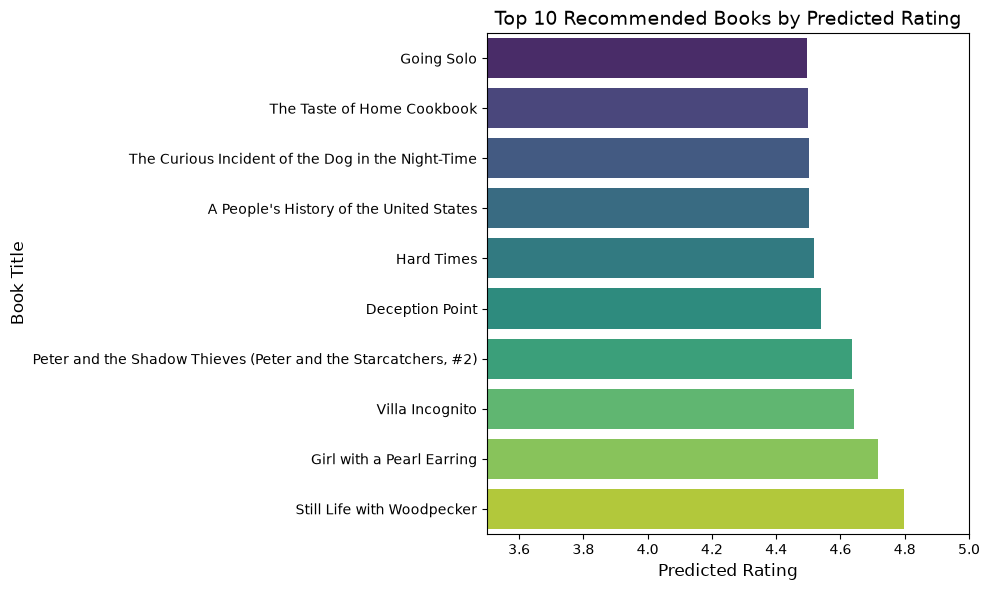


 Visualizing Top 10 Recommendations with Covers:


In [20]:
from IPython.display import HTML, display

# 1. Bar Chart for Top 10 Recommendations
top_books = get_top_n_recommendations_for_user(user_id=1, n=10)
top_books_sorted = top_books.sort_values(by='predicted_rating', ascending=True)

plt.figure(figsize=(10, 6))
# Using seaborn barplot
sns.barplot(x='predicted_rating', y='title', data=top_books_sorted, palette='viridis')
plt.title('Top 10 Recommended Books by Predicted Rating', fontsize=14)
plt.xlabel('Predicted Rating', fontsize=12)
plt.ylabel('Book Title', fontsize=12)
plt.xlim(3.5, 5.0) # Zooming in on the relevant rating scale
plt.tight_layout()
plt.show()

# 2. Grid Display with Book Covers
def display_books_grid(books_df):
    html = '<div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: center;">'
    # Show highest rating first
    for _, row in books_df.sort_values(by='predicted_rating', ascending=False).iterrows():
        html += f'''
        <div style="width: 160px; text-align: center; font-family: Arial, sans-serif; box-shadow: 0 4px 10px rgba(0,0,0,0.1); border-radius: 12px; padding: 12px; background-color: #ffffff; transition: transform 0.2s;">
            <img src="{row['image_url']}" style="width: 100%; height: 210px; object-fit: cover; border-radius: 8px; margin-bottom: 12px;" onerror="this.src='https://via.placeholder.com/150x200?text=No+Cover'">
            <h4 style="font-size: 14px; margin: 0 0 5px 0; color: #2c3e50; height: 38px; overflow: hidden; text-overflow: ellipsis;">{row['title']}</h4>
            <p style="font-size: 11px; margin: 0; color: #7f8c8d; height: 32px; overflow: hidden;">{row['authors']}</p>
            <div style="margin-top: 8px; padding: 4px; background-color: #fef9e7; border-radius: 6px; border: 1px solid #f1c40f;">
                <p style="font-size: 13px; margin: 0; font-weight: bold; color: #d35400;"> Pred: {row['predicted_rating']:.2f}</p>
            </div>
        </div>
        '''
    html += '</div>'
    display(HTML(html))

print("\n Visualizing Top 10 Recommendations with Covers:")
display_books_grid(top_books)


## 6. References *(APA 7th Edition)*

- Hug, N. (2020). Surprise: A Python library for recommender systems. *Journal of Open Source Software*, *5*(52), 2174. https://doi.org/10.21105/joss.02174  
- McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 51–56). https://doi.org/10.25080/Majora-92bf1922-00a  
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.
